In [5]:
# class Value:
#     def __init__(self,data):
#         self.data=data

#     def __add__(self, other):
#         other=other if isinstance(other, Value) else Value(other)
#         return Value(self.data+other.data)

#     def __mul__(self, other):
#         other=other if isinstance(other, Value) else Value(other)
#         return Value(self.data*other.data)

#     def __repr__(self):
#         return f"Value(data={self.data})"
        

In [85]:
# class Value:
#     def __init__(self,data, _children=(), _op=''):
#         self.data=data
#         self._prev=set(_children)
#         self._op=_op
#         self._backward=lambda:None
#         self.grad=0
#     def __add__(self, other):
#         other=other if isinstance(other, Value) else Value(other)
#         out=Value(self.data+other.data, _children=(self, other), _op='+')
#         def _backward():
#             self.grad+=out.grad
#             other.grad+=out.grad
#         out._backward=_backward
#         return out
#     def __mul__(self,other):
#         other=other if isinstance(other, Value) else Value(other)
#         out=Value(self.data*other.data, _children=(self,other), _op='*')
#         def _backward():
#             self.grad+=other.data*out.grad
#             other.grad+=self.data*out.grad
#         out._backward=_backward
#         return out
#     def backward(self):
#         topo=[]
#         visited=set()
#         def dfs(node):
#             if node not in visited:
#                 visited.add(node)
#                 for child in node._prev:
#                     dfs(child)
#                 topo.append(node)
#         dfs(self)
#         self.grad=1.0
#         for i in reversed(topo):
#             i._backward()
            
#     def __repr__(self):
#         return f"Value(data={self.data})"
    

In [10]:
# out=Value(self.data**n, _children(self), _op=f'**{n}')
# x**n, only the x values(the values w.r.t which we derive) are in _children.

In [2]:
import sys
!{sys.executable} -m pip install graphviz

In [37]:
import sys
!{sys.executable} -m pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 25.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 29.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]


In [15]:
!brew install graphviz

==> Auto-updating Homebrew...
Adjust how often this is run with `$HOMEBREW_AUTO_UPDATE_SECS` or disable with
`$HOMEBREW_NO_AUTO_UPDATE=1`. Hide these hints with `$HOMEBREW_NO_ENV_HINTS=1` (see `man brew`).
==> Auto-updated Homebrew!
Updated 2 taps (homebrew/core and homebrew/cask).
==> New Formulae
cc-connect: Bridges local AI coding agents to messaging platforms
erfa: Essential Routines for Fundamental Astronomy
floresta: Lightweight and embeddable Bitcoin client, built for sovereignty
forgecode: AI-enhanced terminal development environment
hf-mount: Mount Hugging Face Buckets and repos as local filesystems
lazymake: Modern TUI for Makefiles
mcp-remote: Remote proxy for Model Context Protocol with OAuth support
odinfmt: Formatter for The Odin Programming Language
ols: Language server for The Odin Programming Language
openssl@4: Cryptography and SSL/TLS Toolkit
rabbitmqadmin: Command-line tool for RabbitMQ that uses the HTTP API
sdl3_mixer: Sample multi-channel audio mixer library
try:

In [29]:
import math

In [30]:
import random

In [31]:
import graphviz
print(graphviz.__version__)

0.21


In [7]:
a=Value(201)
b=Value(-4)
c=a+b
print(c)

Value(data=197)


In [92]:
a=Value(2)
b=Value(-4)
c=a*b
print(c)
print(c._pre)
print(c._op)

Value(data=-8)
{Value(data=2), Value(data=-4)}
*


In [96]:
a=Value(3)
b=Value(-4)
c=a+b
c.grad= 1.0
c._backward()
print(a.grad)
print(b.grad)

1.0
1.0


In [115]:
a=Value(2)
b=Value(-4)
c=Value(8)
d=a*b
e=d+c
e.backward()
print(a.grad)
print(b.grad)
print(c.grad)
print(d.grad)
print(e.grad)

-4.0
2.0
1.0
1.0
1.0


In [23]:
a = Value(2.0)

print(a ** 3)      # Value(data=8.0)
print(a.exp())     # Value(data=7.389...)
print(a.tanh())    # Value(data=0.964...)
print(a.relu())    # Value(data=2.0)

b = Value(-1.0)
print(b.relu())    # Value(data=0.0)  ← negative input gets killed

# Test gradients
x = Value(0.5)
y = x.tanh()
y.backward()
print(x.grad)      # 0.786...  (= 1 - tanh²(0.5))

Value(data=8.0)
Value(data=7.38905609893065)
Value(data=0.9640275800758169)
Value(data=2.0)
Value(data=0)
0.7864477329659274


In [6]:
class Value:
    def __init__(self,data,_children=(),_op=''):
        self.data=data
        self._pre=set(_children)
        self._op=_op
        self.grad=0
        self._backward=lambda:None
    def __add__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data+other.data, _children=(self,other), _op='+')
        def _backward():
            self.grad+=out.grad
            other.grad+=out.grad
        out._backward=_backward
        return out
    def __mul__(self,other):
        other=other if isinstance(other, Value) else Value(other)
        out=Value(self.data*other.data, _children=(self,other), _op='*')
        def _backward():
            self.grad+=other.data*out.grad
            other.grad+=self.data*out.grad
        out._backward=_backward
        return out
    def __pow__(self,n):
        assert isinstance(n,(int,float)), "exponent must be number"
        out=Value(self.data**n, _children=(self,), _op=f'**{n}')
        def _backward():
            self.grad+=(n*(self.data**(n-1)))*out.grad
        out._backward=_backward
        return out
    def exp(self):
        out=Value(math.exp(self.data), _children=(self,), _op='exp')
        def _backward():
            self.grad+=out.data*out.grad
        out._backward=_backward
        return out
    def tanh(self):
        t=math.tanh(self.data)
        out=Value(t, _children=(self,), _op='tanh')
        def _backward():
            self.grad+=(1-t**2)*out.grad
        out._backward=_backward
        return out
    def relu(self):
        r= self.data if self.data>0 else 0
        out=Value(r,_children=(self,), _op='relu')
        def _backward():
            self.grad+=(out.data>0)*out.grad
        out._backward=_backward
        return out
    def __radd__(self,other): return self+other
    def __rmul__(self,other): return self*other
    def __sub__(self,other): return self+(other*-1)
    def __neg__(self): return self*(-1)
    def __truediv__(self,other): return self*(other**(-1))
    def backward(self):
        topo=[]
        visited=set()
        def dfs(node):
            if node not in visited:
                visited.add(node)
                for child in node._pre:
                    dfs(child)
                topo.append(node)
        dfs(self)
        self.grad=1.0
        for i in reversed(topo):
            i._backward()
    
    def __repr__(self):
        return f"Value(data={self.data})"

In [20]:
import math

class Value:
    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self._prev = set(_children)   # ← fixed: was self._pre
        self._op = _op
        self.grad = 0.0
        self._backward = lambda: None

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, _children=(self, other), _op='+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, _children=(self, other), _op='*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, n):
        assert isinstance(n, (int, float)), "exponent must be a number"
        out = Value(self.data ** n, _children=(self,), _op=f'**{n}')
        def _backward():
            self.grad += (n * (self.data ** (n - 1))) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        out = Value(math.exp(self.data), _children=(self,), _op='exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        t = math.tanh(self.data)
        out = Value(t, _children=(self,), _op='tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def relu(self):
        out = Value(max(0, self.data), _children=(self,), _op='relu')
        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward
        return out
    def sigmoid(self):
        s = 1 / (1 + math.exp(-self.data))
        out = Value(s, _children=(self,), _op='sigmoid')
        def _backward():
            self.grad += s * (1 - s) * out.grad  # s(1-s)
        out._backward = _backward
        return out

    def leaky_relu(self, alpha=0.01):
        r = self.data if self.data > 0 else alpha * self.data
        out = Value(r, _children=(self,), _op='leaky_relu')
        def _backward():
            self.grad += (1.0 if self.data > 0 else alpha) * out.grad
        out._backward = _backward
        return out
    
    def swish(self):
        s = 1 / (1 + math.exp(-self.data))
        out = Value(self.data * s, _children=(self,), _op='swish')
        def _backward():
            s2 = 1 / (1 + math.exp(-self.data))
            self.grad += (s2 + self.data * s2 * (1 - s2)) * out.grad
        out._backward = _backward
        return out
    def log(self):
        out = Value(math.log(self.data), _children=(self,), _op='log')
        def _backward():
            self.grad += (1 / self.data) * out.grad
        out._backward = _backward
        return out
    def __radd__(self, other): return self + other
    def __rmul__(self, other): return self * other
    def __sub__(self, other):  return self + (other * -1)
    def __neg__(self):         return self * (-1)
    def __truediv__(self, other): return self * (other ** -1)

    def backward(self):
        topo = []
        visited = set()
        def dfs(node):
            if node not in visited:
                visited.add(node)
                for child in node._prev:
                    dfs(child)
                topo.append(node)
        dfs(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = graphviz.Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    
    nodes, edges = trace(root)
    
    for n in nodes:
        # draw a rectangle for every Value node
        dot.node(name=str(id(n)), 
                 label=f"data {n.data:.4f} | grad {n.grad:.4f}", 
                 shape='record')
        
        if n._op:
            # draw a circle for the operation
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

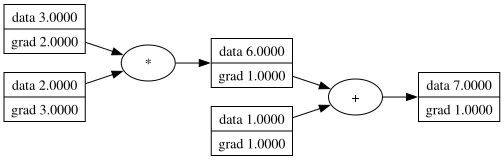

In [18]:
# build a small expression
a = Value(2.0)
b = Value(3.0)
c = a * b + Value(1.0)
c.backward()

# draw it
draw_dot(c)

In [19]:
x = Value(1.5)

print(x.sigmoid())    # Value(data=0.8176, grad=0.0)
print(x.leaky_relu()) # Value(data=1.5,   grad=0.0)
print(x.swish())      # Value(data=1.2269, grad=0.0)

# test gradients
a = Value(1.5)
a.sigmoid().backward()
print(f"sigmoid grad: {a.grad:.4f}")   # 0.1491

b = Value(1.5)
b.leaky_relu().backward()
print(f"leaky_relu grad: {b.grad:.4f}") # 1.0

c = Value(1.5)
c.swish().backward()
print(f"swish grad: {c.grad:.4f}")     # 1.1312

Value(data=0.8175744761936437, grad=0.0)
Value(data=1.5, grad=0.0)
Value(data=1.2263617142904655, grad=0.0)
sigmoid grad: 0.1491
leaky_relu grad: 1.0000
swish grad: 1.0413


In [21]:
class Loss:
    
    @staticmethod
    def mse(ypred, ytrue):
        """Mean Squared Error — regression problems"""
        return sum((yp - yt)**2 for yp, yt in zip(ypred, ytrue)) * (1 / len(ypred))

    @staticmethod
    def mae(ypred, ytrue):
        """Mean Absolute Error — robust to outliers"""
        return sum((yp - yt) if (yp - yt).data > 0 else (yt - yp) 
                   for yp, yt in zip(ypred, ytrue)) * (1 / len(ypred))

    @staticmethod
    def binary_cross_entropy(ypred, ytrue):
        """Binary Cross Entropy — binary classification (targets must be 0 or 1)"""
        eps = 1e-7  # prevent log(0)
        loss = Value(0.0)
        for yp, yt in zip(ypred, ytrue):
            # clamp prediction between eps and 1-eps
            yp_clamped = Value(min(max(yp.data, eps), 1 - eps))
            loss = loss + (
                Value(-yt.data) * yp_clamped.log() +
                Value(-(1 - yt.data)) * (Value(1.0) - yp_clamped).log()
            )
        return loss * (1 / len(ypred))

    @staticmethod
    def hinge(ypred, ytrue):
        """Hinge Loss — SVM-style (targets must be -1 or +1)"""
        losses = []
        for yp, yt in zip(ypred, ytrue):
            margin = Value(1.0) - Value(yt.data) * yp
            losses.append(Value(max(0, margin.data)))
        return sum(losses) * (1 / len(losses))

In [32]:
model = MLP(3, [4, 4, 1])

xs = [
    [Value(2.0),  Value(3.0),  Value(-1.0)],
    [Value(3.0),  Value(-1.0), Value(0.5)],
    [Value(0.5),  Value(1.0),  Value(1.0)],
    [Value(1.0),  Value(1.0),  Value(-1.0)],
]
ys = [Value(1.0), Value(-1.0), Value(-1.0), Value(1.0)]

ypred = [model(x) for x in xs]

mse   = Loss.mse(ypred, ys)
mae   = Loss.mae(ypred, ys)
hinge = Loss.hinge(ypred, ys)

print(f"MSE Loss:   {mse.data:.4f}")
print(f"MAE Loss:   {mae.data:.4f}")
print(f"Hinge Loss: {hinge.data:.4f}")

MSE Loss:   1.8637
MAE Loss:   1.0625
Hinge Loss: 1.0625


In [35]:
class DataLoader:
    def __init__(self, xs, ys, batch_size=2, shuffle=True):
        self.xs = xs
        self.ys = ys
        self.batch_size = batch_size
        self.shuffle = shuffle

    def __iter__(self):
        indices = list(range(len(self.xs)))
        if self.shuffle:
            random.shuffle(indices)
        
        # yield batches one at a time
        for start in range(0, len(indices), self.batch_size):
            batch_idx = indices[start : start + self.batch_size]
            yield (
                [self.xs[i] for i in batch_idx],
                [self.ys[i] for i in batch_idx]
            )

    def __len__(self):
        return len(self.xs) // self.batch_size

In [36]:
# data
xs = [
    [Value(2.0),  Value(3.0),  Value(-1.0)],
    [Value(3.0),  Value(-1.0), Value(0.5)],
    [Value(0.5),  Value(1.0),  Value(1.0)],
    [Value(1.0),  Value(1.0),  Value(-1.0)],
]
ys = [Value(1.0), Value(-1.0), Value(-1.0), Value(1.0)]

model  = MLP(3, [4, 4, 1])
loader = DataLoader(xs, ys, batch_size=2)

for epoch in range(10):
    epoch_loss = 0.0

    for xb, yb in loader:
        # forward
        ypred = [model(x) for x in xb]

        # loss on this batch
        loss = Loss.mse(ypred, yb)

        # zero grads
        for p in model.parameters():
            p.grad = 0.0

        # backward
        loss.backward()

        # update
        for p in model.parameters():
            p.data -= 0.05 * p.grad

        epoch_loss += loss.data

    print(f"epoch {epoch+1:2d} | loss = {epoch_loss / len(loader):.6f}")

epoch  1 | loss = 1.896187
epoch  2 | loss = 1.858565
epoch  3 | loss = 1.801555
epoch  4 | loss = 1.738566
epoch  5 | loss = 1.657004
epoch  6 | loss = 1.189290
epoch  7 | loss = 1.017984
epoch  8 | loss = 0.490072
epoch  9 | loss = 0.303815
epoch 10 | loss = 0.219845


In [23]:
class Neuron:
    def __init__(self,n):
        #n=number of inputs
        self.w=[Value(random.uniform(-1,1)) for _ in range(n)]
        self.b=Value(random.uniform(-1,1))
    def __call__(self,x):
        act=sum((wi*xi for wi,xi in zip(self.w,x)), self.b)
        return act.tanh()
    def parameters(self):
        return self.w+[self.b]
    def __repr__(self):
        return f"number of inputs={len(self.w)}"
        

In [27]:
n = Neuron(3)             # neuron with 3 inputs

x = [Value(1.0), Value(0.5), Value(-1.0)]
out = n(x)

print(out)                # Value(data=some number between -1 and 1)
print(len(n.parameters())) # 4  (3 weights + 1 bias)

out.backward()
for p in n.parameters():
    print(p.grad)         # gradients of each weight and bias

Value(data=-0.16458185561514374)
4
0.9729128128022759
0.48645640640113796
-0.9729128128022759
0.9729128128022759


In [24]:
class Layer:
    def __init__(self, ni, no):
        #ni,no=no.of inputs, no.of outputs
        self.neurons=[Neuron(ni) for _ in range(no)]
    def __call__(self,x):
        outs=[n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs
    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]
        
    def __repr__():
        return f"Layer(neurons={len(self.neurons)})"

In [32]:
l = Layer(3, 4)       # 3 inputs, 4 neurons = 4 outputs

x = [Value(1.0), Value(0.5), Value(-1.0)]
out = l(x)

print(out)            # list of 4 Value objects
print(len(out))       # 4
print(len(l.parameters()))  # 16  (each neuron has 3 weights + 1 bias = 4, times 4 neurons)

[Value(data=0.8301318944167998), Value(data=0.1328058835173005), Value(data=0.8647982718003816), Value(data=-0.838579922197123)]
4
16


In [25]:
class MLP:
    def __init__(self,ni,ls):
        #ls=layer sizes
        sizes=[ni]+ls
        self.layers=[Layer(sizes[i],sizes[i+1]) for i in range(len(ls))]
    def __call__(self,x):
        for layer in self.layers:
            x=layer(x)
        return x
    def parameters(self):
        return [p for l in self.layers for p in l.parameters()]
    def __repr__():
        return f"MLP(layers={len(self.layers)})"

In [33]:
# 3 inputs → hidden layer of 4 → hidden layer of 4 → 1 output
model = MLP(3, [4, 4, 1])

x = [Value(1.0), Value(0.5), Value(-1.0)]
out = model(x)

print(out)                      # Value(data=some number between -1 and 1)
print(len(model.parameters()))  # 41  (explained below)

Value(data=-0.24747466409002114, grad=0.0)
41


In [39]:
# 4 training examples, each with 3 inputs
xs = [
    [Value(2.0),  Value(3.0),  Value(-1.0)],
    [Value(3.0),  Value(-1.0), Value(0.5)],
    [Value(0.5),  Value(1.0),  Value(1.0)],
    [Value(1.0),  Value(1.0),  Value(-1.0)],
]

# desired outputs (targets)
ys = [Value(1.0), Value(-1.0), Value(-1.0), Value(1.0)]

In [34]:
model=MLP(3,[4,4,1])
for step in range(20):
    ypred=[model(x) for x in xs]
    loss=sum((yout-ygt)**2 for yout,ygt in zip(ys,ypred))
    for p in model.parameters():
        p.grad=0.0
    loss.backward()
    for p in model.parameters():
        p.data-=0.05*p.grad
    print(f"step {step:2d} | loss = {loss.data:.6f}")

step  0 | loss = 2.176867
step  1 | loss = 0.872524
step  2 | loss = 0.526598
step  3 | loss = 0.368278
step  4 | loss = 0.277903
step  5 | loss = 0.219986
step  6 | loss = 0.180328
step  7 | loss = 0.151775
step  8 | loss = 0.130395
step  9 | loss = 0.113877
step 10 | loss = 0.100786
step 11 | loss = 0.090189
step 12 | loss = 0.081459
step 13 | loss = 0.074158
step 14 | loss = 0.067971
step 15 | loss = 0.062669
step 16 | loss = 0.058082
step 17 | loss = 0.054077
step 18 | loss = 0.050554
step 19 | loss = 0.047432


In [44]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── build & train a fresh model ──────────────────────────────────────────────
xs_train = [
    [Value(2.0),  Value(3.0),  Value(-1.0)],
    [Value(3.0),  Value(-1.0), Value(0.5)],
    [Value(0.5),  Value(1.0),  Value(1.0)],
    [Value(1.0),  Value(1.0),  Value(-1.0)],
]
ys_train = [Value(1.0), Value(-1.0), Value(-1.0), Value(1.0)]

demo_model = MLP(3, [4, 4, 1])

def train_model(epochs, lr):
    for _ in range(epochs):
        ypred = [demo_model(x) for x in xs_train]
        loss  = Loss.mse(ypred, ys_train)
        for p in demo_model.parameters():
            p.grad = 0.0
        loss.backward()
        for p in demo_model.parameters():
            p.data -= lr * p.grad
    return loss.data

# ── widgets ───────────────────────────────────────────────────────────────────
title = widgets.HTML("<h2>🧠 Micrograd Interactive Demo</h2>")

epoch_slider = widgets.IntSlider(
    value=10, min=1, max=100, step=1,
    description='Epochs:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

lr_slider = widgets.FloatSlider(
    value=0.05, min=0.001, max=0.2, step=0.001,
    description='Learning Rate:',
    readout_format='.3f',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

x1 = widgets.FloatText(value=1.0,  description='Input x1:')
x2 = widgets.FloatText(value=0.5,  description='Input x2:')
x3 = widgets.FloatText(value=-1.0, description='Input x3:')

train_btn   = widgets.Button(description='🚀 Train Model',   button_style='success')
predict_btn = widgets.Button(description='🔮 Predict',       button_style='info')
reset_btn   = widgets.Button(description='🔄 Reset Model',   button_style='warning')

output = widgets.Output()

# ── button logic ─────────────────────────────────────────────────────────────
def on_train(b):
    with output:
        clear_output()
        loss = train_model(epoch_slider.value, lr_slider.value)
        print(f"✅ Training complete!")
        print(f"   Epochs:        {epoch_slider.value}")
        print(f"   Learning rate: {lr_slider.value:.3f}")
        print(f"   Final loss:    {loss:.6f}")

def on_predict(b):
    with output:
        clear_output()
        x = [Value(x1.value), Value(x2.value), Value(x3.value)]
        pred = demo_model(x)
        label = "✅ Positive (≈ +1)" if pred.data > 0 else "❌ Negative (≈ -1)"
        print(f"🔮 Prediction for [{x1.value}, {x2.value}, {x3.value}]")
        print(f"   Raw output: {pred.data:.4f}")
        print(f"   Label:      {label}")

def on_reset(b):
    global demo_model
    demo_model = MLP(3, [4, 4, 1])
    with output:
        clear_output()
        print("🔄 Model reset — weights re-randomized!")

train_btn.on_click(on_train)
predict_btn.on_click(on_predict)
reset_btn.on_click(on_reset)

# ── layout ────────────────────────────────────────────────────────────────────
display(widgets.VBox([
    title,
    widgets.HTML("<b>Training Settings</b>"),
    epoch_slider,
    lr_slider,
    widgets.HBox([train_btn, reset_btn]),
    widgets.HTML("<hr><b>Run a Prediction</b>"),
    widgets.HBox([x1, x2, x3]),
    predict_btn,
    widgets.HTML("<hr><b>Output</b>"),
    output
]))

In [42]:
!jupyter labextension list

JupyterLab v4.5.6
/opt/homebrew/Cellar/jupyterlab/4.5.6_2/libexec/share/jupyter/labextensions
        jupyterlab_pygments v0.3.0 enabled OK (python, jupyterlab_pygments)
        @jupyter-notebook/lab-extension v7.5.5 enabled OK
        @jupyter-widgets/jupyterlab-manager v5.0.15 enabled OK (python, jupyterlab_widgets)



In [45]:
!git --version

git version 2.53.0


In [46]:
!gh --version


]11;?\]11;?\gh version 2.72.0 (2025-04-30)
https://github.com/cli/cli/releases/tag/v2.72.0


In [47]:
!gh --version

]11;?\]11;?\gh version 2.72.0 (2025-04-30)
https://github.com/cli/cli/releases/tag/v2.72.0


In [48]:
gh auth login

SyntaxError: invalid syntax (3568707134.py, line 1)